[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Long Short-Term Memory (LSTM)

In the previous notebook we saw — and measured directly — that vanilla RNNs suffer from vanishing and exploding gradients, and consequently have trouble learning long-term dependencies (see Bengio et al. 1994; Hochreiter et al. 2001).  Hochreiter had articulated this problem as early as 1991 in his Master's thesis, although the results were not widely known.  While gradient clipping helps with exploding gradients, handling vanishing gradients requires a more elaborate solution.  One of the first and most successful techniques for addressing vanishing gradients came in the form of the **long short-term memory** (LSTM) model due to Hochreiter and Schmidhuber (1997).

LSTMs resemble standard recurrent neural networks, but each ordinary recurrent node is replaced by a **memory cell**.  Each memory cell contains an *internal state*, i.e., a node with a self-connected recurrent edge of fixed weight 1, ensuring that information (and the gradient) can pass across many time steps without vanishing or exploding.

The term "long short-term memory" comes from the following intuition.  Standard RNNs have *short-term memory* in the form of their hidden state, which passes from step to step but, as we saw, is easily overwritten and hard to preserve.  The memory cell gives the network a protected place to keep information around for the *long* term.

As a reminder, the vanilla RNN maintains its entire memory in the hidden state, updated at every step as

$$\mathbf{H}_t = \tanh(\mathbf{X}_t \mathbf{W}_{\textrm{xh}} + \mathbf{H}_{t-1} \mathbf{W}_{\textrm{hh}} + \mathbf{b}_\textrm{h}),$$

so *every* input rewrites *all* of the state through the saturating $\tanh$.  The LSTM's key move is to make updating the memory a *decision* rather than an automatic consequence of seeing an input.

In [1]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
from matplotlib import pyplot as plt

torch.manual_seed(0);

## Components of an LSTM unit

### Gated memory

The key distinction between vanilla RNNs and LSTMs is that the latter support *gating* of the memory.  This means that we have dedicated, learned mechanisms that decide *when* the memory should be updated, *what* should be written into it, and *when* it should be read out.  For instance, if the first token is of great importance, the network can learn to write it into the memory cell and then keep the cell unchanged for the rest of the sequence; likewise it can learn to ignore irrelevant observations, and to reset the memory when its content is no longer needed.

### Input gate, forget gate, and output gate

The data feeding into the LSTM gates are the input at the current time step and the hidden state of the previous time step, as illustrated below.  Three fully connected layers with sigmoid activation functions compute the values of the input, forget, and output gates.  As a result of the sigmoid activation, all values of the three gates are in the range $(0, 1)$.  Additionally, we require an *input node*, typically computed with a $\tanh$ activation function.

Intuitively:

* the **input gate** determines how much of the input node's value should be added to the current memory cell internal state,
* the **forget gate** determines whether to keep the current value of the memory or flush it, and
* the **output gate** determines whether the memory cell should influence the output at the current time step.

![Computing the input gate, the forget gate, and the output gate in an LSTM model.](https://github.com/d2l-ai/d2l-en/raw/refs/heads/master/img/lstm-0.svg)

Mathematically, suppose that there are $h$ hidden units, the batch size is $n$, and the number of inputs is $d$.  Thus, the input is $\mathbf{X}_t \in \mathbb{R}^{n \times d}$ and the hidden state of the previous time step is $\mathbf{H}_{t-1} \in \mathbb{R}^{n \times h}$.  The gates at time step $t$ are the input gate $\mathbf{I}_t \in \mathbb{R}^{n \times h}$, the forget gate $\mathbf{F}_t \in \mathbb{R}^{n \times h}$, and the output gate $\mathbf{O}_t \in \mathbb{R}^{n \times h}$, calculated as follows:

$$
\begin{aligned}
\mathbf{I}_t &= \sigma(\mathbf{X}_t \mathbf{W}_{\textrm{xi}} + \mathbf{H}_{t-1} \mathbf{W}_{\textrm{hi}} + \mathbf{b}_\textrm{i}),\\
\mathbf{F}_t &= \sigma(\mathbf{X}_t \mathbf{W}_{\textrm{xf}} + \mathbf{H}_{t-1} \mathbf{W}_{\textrm{hf}} + \mathbf{b}_\textrm{f}),\\
\mathbf{O}_t &= \sigma(\mathbf{X}_t \mathbf{W}_{\textrm{xo}} + \mathbf{H}_{t-1} \mathbf{W}_{\textrm{ho}} + \mathbf{b}_\textrm{o}),
\end{aligned}
$$

where, as in the vanilla RNN, every term must map into the $h$-dimensional hidden space: the input-to-hidden weights $\mathbf{W}_{\textrm{xi}}, \mathbf{W}_{\textrm{xf}}, \mathbf{W}_{\textrm{xo}} \in \mathbb{R}^{d \times h}$, the hidden-to-hidden weights $\mathbf{W}_{\textrm{hi}}, \mathbf{W}_{\textrm{hf}}, \mathbf{W}_{\textrm{ho}} \in \mathbb{R}^{h \times h}$, and the biases $\mathbf{b}_\textrm{i}, \mathbf{b}_\textrm{f}, \mathbf{b}_\textrm{o} \in \mathbb{R}^{1 \times h}$ (broadcast across the minibatch).  The *input node* $\tilde{\mathbf{C}}_t \in \mathbb{R}^{n \times h}$ computes a candidate value to be written into the memory, using the familiar $\tanh$:

$$\tilde{\mathbf{C}}_t = \tanh(\mathbf{X}_t \mathbf{W}_{\textrm{xc}} + \mathbf{H}_{t-1} \mathbf{W}_{\textrm{hc}} + \mathbf{b}_\textrm{c}).$$

### Updating the memory cell

The forget and input gates control the update of the memory cell internal state $\mathbf{C}_t \in \mathbb{R}^{n \times h}$: the forget gate decides how much of the old memory to keep, and the input gate decides how much of the candidate to add:

$$\mathbf{C}_t = \mathbf{F}_t \odot \mathbf{C}_{t-1} + \mathbf{I}_t \odot \tilde{\mathbf{C}}_t,$$

where $\odot$ is elementwise multiplication.  If $\mathbf{F}_t \approx \mathbf{1}$ and $\mathbf{I}_t \approx \mathbf{0}$, the memory is carried over unchanged — this is the "self-connected edge of weight 1" that lets gradients flow untouched across many steps.  Note also that $\mathbf{C}_t$ is *not* passed through a squashing nonlinearity, so unlike the vanilla RNN state it can accumulate values well outside $(-1, 1)$.

### The hidden state

Finally, the hidden state $\mathbf{H}_t$ — what the rest of the network (and the next time step) gets to see — is a gated read-out of the memory:

$$\mathbf{H}_t = \mathbf{O}_t \odot \tanh(\mathbf{C}_t).$$

Whenever the output gate is close to 1, the memory is exposed; when it is close to 0, the memory is retained *privately* inside the cell without affecting the output.

![Computing the hidden state in an LSTM model.](https://github.com/d2l-ai/d2l-en/raw/refs/heads/master/img/lstm-3.svg)

## Implementation from scratch

We now implement the LSTM exactly as described by the equations.  As with our from-scratch RNN, the forward pass loops over time steps; the only difference is what happens inside the loop.

In [2]:
class LSTMScratch(nn.Module):
    def __init__(self, num_inputs, num_hiddens, sigma=0.1):
        super().__init__()
        self.num_hiddens = num_hiddens
        init_weight = lambda *shape: nn.Parameter(torch.randn(*shape) * sigma)
        triple = lambda: (init_weight(num_inputs, num_hiddens),
                          init_weight(num_hiddens, num_hiddens),
                          nn.Parameter(torch.zeros(num_hiddens)))
        self.W_xi, self.W_hi, self.b_i = triple()  # Input gate
        self.W_xf, self.W_hf, self.b_f = triple()  # Forget gate
        self.W_xo, self.W_ho, self.b_o = triple()  # Output gate
        self.W_xc, self.W_hc, self.b_c = triple()  # Input node

    def one_step(self, X, H, C):
        """Compute all quantities for a single time step."""
        I = torch.sigmoid(X @ self.W_xi + H @ self.W_hi + self.b_i)
        F_ = torch.sigmoid(X @ self.W_xf + H @ self.W_hf + self.b_f)
        O = torch.sigmoid(X @ self.W_xo + H @ self.W_ho + self.b_o)
        C_tilde = torch.tanh(X @ self.W_xc + H @ self.W_hc + self.b_c)
        C = F_ * C + I * C_tilde
        H = O * torch.tanh(C)
        return H, C, I, F_, O

    def forward(self, inputs, H_C=None):
        # inputs shape: (num_steps, batch_size, num_inputs)
        if H_C is None:
            H = torch.zeros(inputs.shape[1], self.num_hiddens,
                            device=inputs.device)
            C = torch.zeros_like(H)
        else:
            H, C = H_C
        outputs = []
        for X_t in inputs:
            H, C, _, _, _ = self.one_step(X_t, H, C)
            outputs.append(H)
        return torch.stack(outputs), (H, C)

## Back to the counting task

Let's train the LSTM on the same task we used for the vanilla RNN: classify whether a sequence over $\{\texttt{a}, \texttt{b}\}$ contains more `b`s than `a`s.  We repeat the data-generation and training code from the previous notebook so this notebook is self-contained.

In [3]:
def make_counting_data(num_examples, seq_len, seed=0):
    """Random a/b sequences; label 1 if the sequence has more b's than a's."""
    g = torch.Generator().manual_seed(seed)
    tokens = torch.randint(0, 2, (num_examples, seq_len), generator=g)
    labels = (tokens.sum(dim=1) > seq_len // 2).long()
    X = F.one_hot(tokens, num_classes=2).float()
    return X, labels, tokens

seq_len = 21
X_train, y_train, tokens_train = make_counting_data(4000, seq_len, seed=0)
X_test, y_test, tokens_test = make_counting_data(1000, seq_len, seed=1)
train_iter = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_train, y_train),
    batch_size=64, shuffle=True)

In [4]:
class LSTMClassifier(nn.Module):
    """An LSTM followed by a linear read-out of the final hidden state."""
    def __init__(self, lstm, num_hiddens, num_classes=2):
        super().__init__()
        self.lstm = lstm
        self.decoder = nn.Linear(num_hiddens, num_classes)

    def forward(self, X):
        outputs, (H, C) = self.lstm(X.permute(1, 0, 2))
        return self.decoder(H)

num_hiddens = 4
model = LSTMClassifier(LSTMScratch(num_inputs=2, num_hiddens=num_hiddens),
                       num_hiddens)

In [5]:
def evaluate_accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        preds = model(X).argmax(dim=1)
    return (preds == y).float().mean().item()

def train(model, train_iter, X_test, y_test, epochs=20, lr=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    loss_train, acc_test = [], []
    for epoch in range(epochs):
        model.train()
        loss_values = []
        for batch_X, batch_y in train_iter:
            loss = loss_fn(model(batch_X), batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_values.append(loss.item())
        loss_train.append(np.mean(loss_values))
        acc_test.append(evaluate_accuracy(model, X_test, y_test))
        print(f'epoch {epoch + 1:2d}  loss {loss_train[-1]:.3f}  '
              f'test accuracy {acc_test[-1]:.3f}')
    return loss_train, acc_test

loss_train, acc_test = train(model, train_iter, X_test, y_test)

epoch  1  loss 0.434  test accuracy 0.927


epoch  2  loss 0.115  test accuracy 0.995


epoch  3  loss 0.065  test accuracy 0.988


epoch  4  loss 0.043  test accuracy 0.995


epoch  5  loss 0.025  test accuracy 0.997


...

epoch 16  loss 0.002  test accuracy 1.000


epoch 17  loss 0.003  test accuracy 0.999


epoch 18  loss 0.001  test accuracy 1.000


epoch 19  loss 0.001  test accuracy 1.000


epoch 20  loss 0.001  test accuracy 1.000


## Looking inside: the memory cell as a counter

For the vanilla RNN we watched the hidden state implement a counter with saturating $\tanh$ units.  The LSTM gives us more to look at: for each hidden unit we can record the memory cell $\mathbf{C}_t$, the hidden state $\mathbf{H}_t$, and the values of the three gates at every time step.

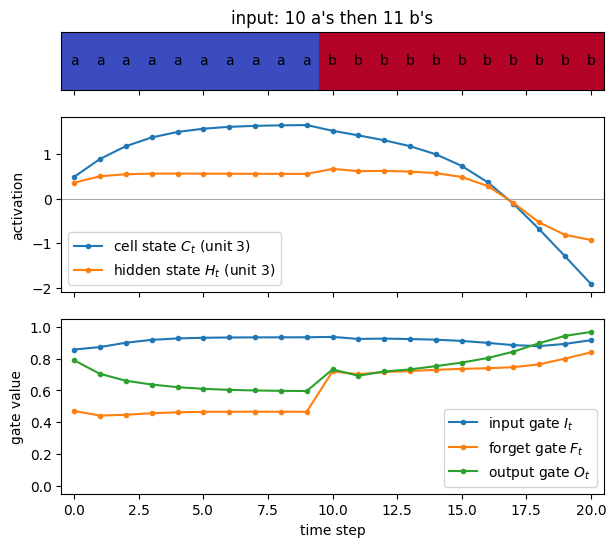

In [6]:
def trace_lstm(lstm, tokens):
    """Run one sequence step by step, recording all internal quantities."""
    X = F.one_hot(tokens, num_classes=2).float()
    H = torch.zeros(1, lstm.num_hiddens)
    C = torch.zeros_like(H)
    rec = {k: [] for k in ['H', 'C', 'I', 'F', 'O']}
    with torch.no_grad():
        for X_t in X:
            H, C, I, F_, O = lstm.one_step(X_t.unsqueeze(0), H, C)
            for k, v in zip(['H', 'C', 'I', 'F', 'O'], [H, C, I, F_, O]):
                rec[k].append(v.squeeze(0))
    return {k: torch.stack(v) for k, v in rec.items()}  # (seq_len, num_hiddens)

# a block of a's followed by a block of b's
tokens_blocks = torch.tensor([0] * 10 + [1] * 11)
rec = trace_lstm(model.lstm, tokens_blocks)

# the hidden unit the decoder relies on most
u = (model.decoder.weight[1] - model.decoder.weight[0]).abs().argmax().item()

fig, axes = plt.subplots(3, 1, figsize=(7, 6), sharex=True,
                         height_ratios=[1, 3, 3])
axes[0].imshow(tokens_blocks.reshape(1, -1), cmap='coolwarm', aspect='auto')
for t, tok in enumerate(tokens_blocks):
    axes[0].text(t, 0, 'ab'[tok], ha='center', va='center')
axes[0].set_yticks([]); axes[0].set_title("input: 10 a's then 11 b's")

axes[1].plot(rec['C'][:, u], marker='.', label=f'cell state $C_t$ (unit {u})')
axes[1].plot(rec['H'][:, u], marker='.', label=f'hidden state $H_t$ (unit {u})')
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].set_ylabel('activation'); axes[1].legend()

axes[2].plot(rec['I'][:, u], marker='.', label='input gate $I_t$')
axes[2].plot(rec['F'][:, u], marker='.', label='forget gate $F_t$')
axes[2].plot(rec['O'][:, u], marker='.', label='output gate $O_t$')
axes[2].set_ylim(-0.05, 1.05)
axes[2].set_xlabel('time step'); axes[2].set_ylabel('gate value')
axes[2].legend();

What do we see?

* The **cell state** $C_t$ behaves like a counter: it climbs through the run of `a`s and reverses direction as soon as the `b`s begin, crossing zero roughly where the counts balance out.  Because the cell update is *additive* — new evidence is added to the old value instead of rewriting the whole state through a squashing nonlinearity — the cell drifts well outside $(-1, 1)$, something the vanilla RNN's $\tanh$ hidden state cannot do.
* The **gates are input-dependent**: the forget and input gates take visibly different values on `a` steps than on `b` steps.  The network is not applying one fixed update rule; at each step it decides, based on the token, how much of the old memory to keep and how much of the candidate value to write.
* The **hidden state** $H_t$ is the squashed, output-gated read-out of the cell — the only version of the memory that the classifier (and the next time step) gets to see.

Nobody programmed a counter; the gates simply give the optimizer the parts from which one can be built.  Look closely, though: the forget gate is *not* pinned at 1, so the network has learned a **leaky** counter in which old evidence gradually fades.  On length-21 sequences a mild leak costs nothing, so gradient descent — which only ever saw length-21 sequences — had no reason to build a perfect integrator.  A forget gate of exactly 1 would implement the "self-connected edge of weight 1" from the introduction: memory (and gradients) carried indefinitely.

The leak has consequences we can measure.  Recall that the vanilla RNN's accuracy decayed as we tested beyond the training length:

In [7]:
for L in [21, 41, 81, 161, 321]:
    X_long, y_long, _ = make_counting_data(1000, L, seed=2)
    print(f'length {L:3d}: accuracy {evaluate_accuracy(model, X_long, y_long):.3f}')

length  21: accuracy 1.000
length  41: accuracy 0.984


length  81: accuracy 0.918
length 161: accuracy 0.815
length 321: accuracy 0.725


The LSTM holds up noticeably better than the vanilla RNN at moderate lengths (compare with the corresponding table in the previous notebook), but it too degrades eventually — its counter leaks.  The lesson is worth stating carefully: the LSTM **architecture** makes reliable long-term memory *available* (set the forget gate to 1 and the memory is perfect), but gradient descent only builds what the training data demands.  Exercise 3 explores a classic practical trick — initializing the forget-gate bias to a positive value — that nudges the network toward remembering.

## Concise implementation

Using the high-level API, we can directly instantiate an LSTM layer with `nn.LSTM`.  This encapsulates all the details we made explicit above and runs significantly faster, as the time loop happens in compiled code rather than Python.

In [8]:
class LSTMConciseClassifier(nn.Module):
    def __init__(self, num_inputs, num_hiddens, num_classes=2):
        super().__init__()
        self.lstm = nn.LSTM(num_inputs, num_hiddens)
        self.decoder = nn.Linear(num_hiddens, num_classes)

    def forward(self, X):
        outputs, (H, C) = self.lstm(X.permute(1, 0, 2))
        return self.decoder(H[-1])  # H has an extra leading layer axis

model_concise = LSTMConciseClassifier(num_inputs=2, num_hiddens=num_hiddens)
loss_train, acc_test = train(model_concise, train_iter, X_test, y_test,
                             epochs=10)

epoch  1  loss 0.451  test accuracy 0.967


epoch  2  loss 0.113  test accuracy 0.978
epoch  3  loss 0.059  test accuracy 0.987
epoch  4  loss 0.035  test accuracy 0.988


epoch  5  loss 0.025  test accuracy 0.999


epoch  6  loss 0.012  test accuracy 1.000
epoch  7  loss 0.008  test accuracy 1.000
epoch  8  loss 0.006  test accuracy 1.000


epoch  9  loss 0.004  test accuracy 1.000


epoch 10  loss 0.004  test accuracy 1.000


## Deep and bidirectional RNNs

Two architectural extensions will be useful when we move to real text.

**Deep RNNs.**  Just like MLPs and CNNs, recurrent layers can be stacked: the sequence of hidden states produced by one layer serves as the input sequence of the next.  In PyTorch this is the `num_layers` argument of `nn.LSTM`.

![A deep RNN.](https://github.com/d2l-ai/d2l-en/raw/refs/heads/master/img/deep-rnn.svg)

**Bidirectional RNNs.**  In a unidirectional RNN, the state at time $t$ knows only about the *past* $\mathbf{X}_1, \ldots, \mathbf{X}_t$.  For classification we get to see the whole sequence at once, and the future context matters.  Consider filling in the blank:

* I am `___`.
* I am `___` hungry.
* I am `___` hungry, and I can eat half a pig.

Depending on what comes *after* the blank, "happy" or "not" or "very" become more or less likely.  A **bidirectional RNN** (Schuster & Paliwal, 1997) runs two recurrent chains over the same input — one left-to-right, one right-to-left — and concatenates their hidden states, so the representation of each position sees the entire sequence.  In PyTorch this is `bidirectional=True`.

![A bidirectional RNN.](https://github.com/d2l-ai/d2l-en/raw/refs/heads/master/img/birnn.svg)

We will use a deep bidirectional LSTM in the next notebooks to classify movie reviews.

## Summary

While LSTMs were published in 1997, they rose to great prominence with some victories in prediction competitions in the mid-2000s, and became the dominant models for sequence learning from 2011 until the rise of Transformer models, starting in 2017.  Even Transformers owe some of their key ideas to architecture design innovations introduced in the LSTM.  A popular simplified variant, the **gated recurrent unit** (GRU), merges the memory cell into the hidden state and uses two gates instead of three.

* LSTMs have three types of gates — input, forget, and output — that control how information flows into, stays in, and is read out of a memory cell.
* The memory cell is updated *additively*, and with the forget gate near 1 it can carry information (and gradients) across many time steps: this is what alleviates the vanishing gradient problem.
* Only the hidden state is passed on to the output layer; the memory cell's internal state remains entirely internal.
* On the counting task, the trained gates turn the cell into a (slightly leaky) counter that extrapolates beyond the training length better than the vanilla RNN.  What the network remembers — and for how long — is determined by the training objective, not by the architecture alone.

## Exercises

1. Trace the gates on the *alternating* sequence `ababab...`.  Do the gate values differ for `a` versus `b` inputs?  How does the cell state move?
2. Train the LSTM on the **parity** task from the previous notebook's exercises (label 1 if the number of `b`s is odd).  Parity cannot be solved by pure accumulation — the state must *toggle*.  Look at the cell state and gates: what mechanism does the network find, and does it still generalize to longer sequences?
3. What happens if you initialize the forget gate bias `b_f` to a large positive value (say 2.0) before training?  This is a well-known practical trick — explain why it helps, and check whether it speeds up learning on the counting task.
4. Replace the LSTM with a GRU (`nn.GRU`) in the concise classifier.  Compare accuracy and length generalization.